# **Data upload from google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
file_path = '/content/drive/MyDrive/AAI500_Module 4/CDC_data/diabetes_012_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)
print(df.head(10))
df.describe()
df.shape
print(df.loc[df['Diabetes_012'] == 1].shape) # in the binary , it was combined with 0 to become 218334
print(df.loc[df['Diabetes_012'] == 0].shape)
print(df.loc[df['Diabetes_012'] == 2].shape) #only keep this one as the diabete group
#combine the prediabete to non diabete
df.head(10)
df.loc[df["Diabetes_012"]==1, "Diabetes_012"] = 0
df.loc[df["Diabetes_012"]==2, "Diabetes_012"] = 1
df["Diabetes_012"].value_counts()

Mounted at /content/drive
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   
5           0.0     1.0       1.0        1.0  25.0     1.0     0.0   
6           0.0     1.0       0.0        1.0  30.0     1.0     0.0   
7           0.0     1.0       1.0        1.0  25.0     1.0     0.0   
8           2.0     1.0       1.0        1.0  30.0     1.0     0.0   
9           0.0     0.0       0.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0

,count
Diabetes_012,
0.0,218334
1.0,35346


# **Data preprocessing**

since there are three types of data

– Ordinal data type

– binary data type

– numerical data type

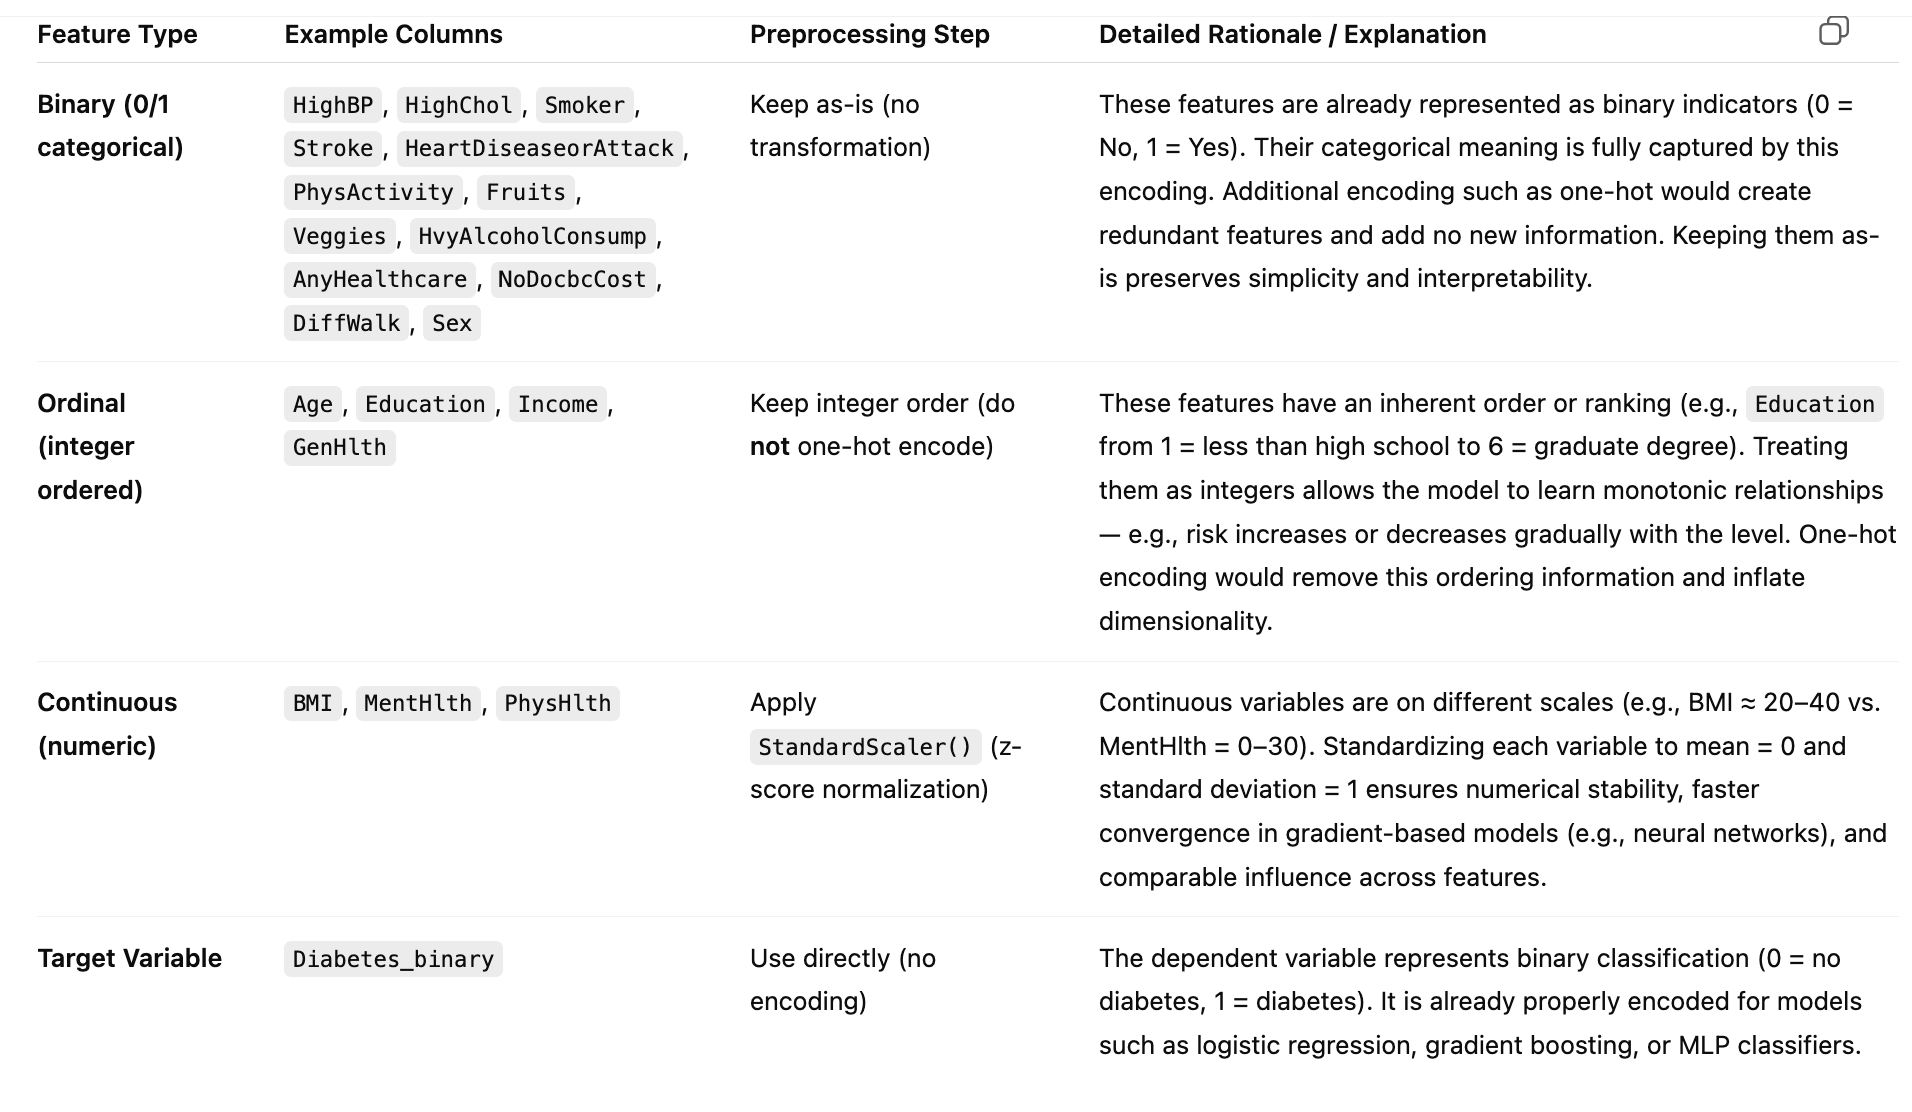

# **Feature selection**

 – mutual inforamtion calculation between target and features. Find the most related features with target

 – Pearson corrlation analysis between features for redundancy detection between features

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# ============ 0) Configuration Section: Fill in your dataset column names ============
TARGET = "Diabetes_012"

BINARY_COLS = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]

ORDINAL_COLS = ["GenHlth", "Age", "Education", "Income"]   # Ordinal integers
NUMERIC_COLS = ["BMI","MentHlth","PhysHlth"]               # Continuous numerical variables

ALL_FEATURES = BINARY_COLS + ORDINAL_COLS + NUMERIC_COLS

TOP_N = 15                 # Number of features to keep
REDUNDANCY_THRESHOLD = 0.6 # Redundancy threshold: two features with |corr| > 0.6 are considered redundant
# Previously set to 0.85; changed to 0.6 because most feature correlations are below 0.3

# ============ 1) Function: Compute Mutual Information & Pearson Correlation ============
def compute_feature_scores(df, target, features, numeric_cols):
    """
    Returns:
      - mi_df:  Mutual Information score table
      - corr_df: Pearson correlation with target (for numeric columns; if target is 0/1, it’s point-biserial correlation)
    """
    X = df[features].copy()
    y = df[target].astype(int).values

    # Ensure numeric data type (both MI and correlation require numeric input)
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    # Mutual Information (works for mixed types; approximates continuous data discretely)
    mi = mutual_info_classif(X.fillna(X.median(numeric_only=True)), y, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({"feature": X.columns, "mutual_info": mi}).sort_values("mutual_info", ascending=False)

    # Pearson correlation with the target (only for numeric columns)
    corr_with_y = {}
    for c in X.columns:
        # Require sufficient non-missing values
        s = X[c]
        mask = s.notna()
        if mask.sum() > 3:
            try:
                corr = np.corrcoef(s[mask].astype(float), y[mask])[0,1]
            except Exception:
                corr = np.nan
        else:
            corr = np.nan
        corr_with_y[c] = corr

    corr_df = pd.DataFrame({"feature": list(corr_with_y.keys()),
                            "pearson_to_y": list(corr_with_y.values())})
    corr_df = corr_df.sort_values("pearson_to_y", key=lambda s: s.abs(), ascending=False)

    return mi_df, corr_df

# ============ 2) Function: Plot Feature–Feature Correlation Heatmap (to check redundancy) ============
def plot_feature_corr_heatmap(df, features, title="Feature-Feature Correlation (abs)"):
    X = df[features].copy()
    # Convert to numeric
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    corr = X.corr(numeric_only=True).abs()  # Take absolute value to show redundancy more clearly

    # --- Draw heatmap using matplotlib only (no seaborn dependency) ---
    fig, ax = plt.subplots(figsize=(max(8, len(features)*0.5), max(6, len(features)*0.5)))
    cax = ax.imshow(corr.values, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks(range(len(features)))
    ax.set_yticks(range(len(features)))
    ax.set_xticklabels(features, rotation=90)
    ax.set_yticklabels(features)

    # Add numeric correlation values on the heatmap
    for i in range(len(features)):
        for j in range(len(features)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", color="black", fontsize=7)

    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return corr

# ============ 3) Function: Select Top N Non-Redundant Features Based on Importance ============
def pick_topN_nonredundant(mi_df, corr_matrix, top_n=10, redundancy_threshold=0.6): # threshold adjusted from 0.85 to 0.6
    """
    Strategy:
      1) Sort features by mutual information descendingly
      2) Iteratively add candidates; if any feature has |corr| > threshold with an already selected one, skip it (considered redundant)
    """
    selected = []
    for feat in mi_df["feature"].tolist():
        if len(selected) >= top_n:
            break
        # Check redundancy with already selected features
        is_redundant = False
        for s in selected:
            if abs(corr_matrix.loc[feat, s]) > redundancy_threshold:
                is_redundant = True
                break
        if not is_redundant:
            selected.append(feat)
    return selected

# ============ 4) —— Example Main Workflow (replace df with your DataFrame) ============
# df = pd.read_csv("your_data.csv")  # Replace with your own data loading method

def run_feature_screening(df):
    # Basic checks
    missing_cols = [c for c in [TARGET] + ALL_FEATURES if c not in df.columns]
    if missing_cols:
        raise ValueError(f"The following columns are missing from df: {missing_cols}")

    # Compute Mutual Information & Pearson correlation with target
    mi_df, corr_to_y_df = compute_feature_scores(
        df=df, target=TARGET, features=ALL_FEATURES, numeric_cols=NUMERIC_COLS
    )

    print("\n=== Top 15 Features by Mutual Information with Target ===")
    print(mi_df.head(21).to_string(index=False)) # changed to 21 to show more


    print("\n=== Top 15 Features by Absolute Pearson Correlation with Target ===")
    print(corr_to_y_df.head(21).to_string(index=False))

    # Plot the feature-feature correlation heatmap and return correlation matrix
    corr_matrix = plot_feature_corr_heatmap(df, ALL_FEATURES)

    # Select Top N non-redundant features (based on MI primarily)
    recommended = pick_topN_nonredundant(mi_df, corr_matrix, top_n=TOP_N, redundancy_threshold=REDUNDANCY_THRESHOLD)

    print(f"\n=== Recommended Top {TOP_N} Features (Mutual Info Priority, Redundancy Threshold={REDUNDANCY_THRESHOLD}) ===")
    print(recommended)

    # Return for programmatic use
    return {
        "mi_table": mi_df,
        "corr_to_target_table": corr_to_y_df,
        "feature_corr_matrix": corr_matrix,
        "recommended_features": recommended
    }

# ======= Usage =======
# result = run_feature_screening(df)
# final_features = result["recommended_features"]



=== Top 15 Features by Mutual Information with Target ===
             feature  mutual_info
             GenHlth     0.054189
              HighBP     0.053140
       AnyHealthcare     0.052478
        PhysActivity     0.049835
           CholCheck     0.048799
             Veggies     0.043121
              Fruits     0.040910
            HighChol     0.040654
                 BMI     0.029930
              Smoker     0.025809
                 Sex     0.024694
                 Age     0.024312
              Income     0.023238
           Education     0.022678
            DiffWalk     0.022206
HeartDiseaseorAttack     0.014188
            PhysHlth     0.013774
              Stroke     0.005485
            MentHlth     0.003768
   HvyAlcoholConsump     0.002985
         NoDocbcCost     0.000838

=== Top 15 Features by Absolute Pearson Correlation with Target ===
             feature  pearson_to_y
             GenHlth      0.293569
              HighBP      0.263129
            DiffWal

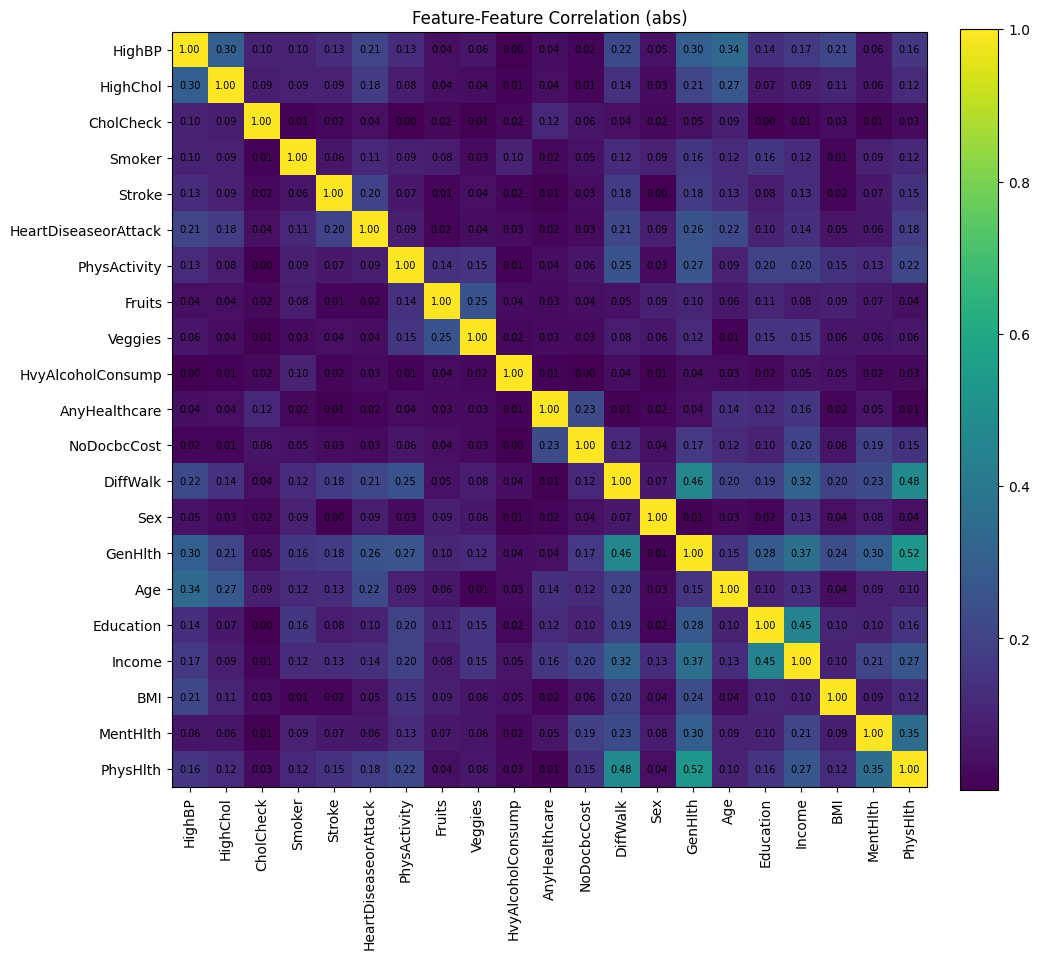


=== Recommended Top 15 Features (Mutual Info Priority, Redundancy Threshold=0.6) ===
['GenHlth', 'HighBP', 'AnyHealthcare', 'PhysActivity', 'CholCheck', 'Veggies', 'Fruits', 'HighChol', 'BMI', 'Smoker', 'Sex', 'Age', 'Income', 'Education', 'DiffWalk']


In [ ]:
result = run_feature_screening(df)
final_features = result["recommended_features"]

# **Model Training (MLP)**

In [ ]:
# ====== Imports ======
import numpy as np
import pandas as pd
from collections import Counter
from copy import deepcopy

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# ====== 1) Columns & selections ======
TARGET = "Diabetes_012"

BINARY_COLS = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]
ORDINAL_COLS = ["GenHlth","Age","Education","Income"]
NUMERIC_COLS = ["BMI","MentHlth","PhysHlth"]

selected_features = [
    'GenHlth','HighBP','AnyHealthcare','PhysActivity','CholCheck','HighChol',
    'Veggies','Fruits','BMI','Age','Smoker','Income','Sex','Education','DiffWalk'
]

def split_types_by_selection(selected):
    bin_used = [c for c in selected if c in BINARY_COLS]
    ord_used = [c for c in selected if c in ORDINAL_COLS]
    num_used = [c for c in selected if c in NUMERIC_COLS]
    return bin_used, ord_used, num_used

bin_used, ord_used, num_used = split_types_by_selection(selected_features)

# ====== 2) Preprocessing pieces ======
# (A) Impute only before SMOTENC; keep categorical as integers
impute_only = ColumnTransformer(
    transformers=[
        ("ord_bin", SimpleImputer(strategy="most_frequent"), bin_used + ord_used),
        ("num",     SimpleImputer(strategy="median"),        num_used),
    ],
    remainder="drop"
)

# (B) After sampling, scale only numeric columns by index
n_cat = len(bin_used) + len(ord_used)
n_num = len(num_used)
cat_mask = [True] * n_cat + [False] * n_num

scale_numeric_by_idx = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), list(range(n_cat, n_cat + n_num))),
    ],
    remainder="passthrough"
)

# ====== 3) Build dataset & splits ======
all_needed = selected_features + [TARGET]
df_use = df[all_needed].copy()  # <-- assumes df is already loaded with these columns

# robust: ensure binary 0/1 for target
y_raw = pd.to_numeric(df_use[TARGET], errors="coerce")
y_bin = (y_raw >= 1).astype(int)  # 1 for class 1/2; 0 otherwise
df_use[TARGET] = y_bin

X = df_use.drop(columns=[TARGET])
y = df_use[TARGET].to_numpy().ravel()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Target counts AFTER mapping 2→1 (global):")
print(pd.Series(y).value_counts().sort_index())
print("y_train class counts:", Counter(y_train))

# ====== 4) Helper: threshold search for Balanced Accuracy ======
def best_threshold_for_balacc(y_true, proba_1):
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t, best_bal = 0.5, -1
    for t in thresholds:
        y_hat = (proba_1 >= t).astype(int)
        bal = balanced_accuracy_score(y_true, y_hat)
        if bal > best_bal:
            best_bal, best_t = bal, t
    return best_t, best_bal

# ====== 4b) Helper: compute & plot Confusion Matrix, ROC, PR, Reliability ======
def eval_and_plots(y_true, proba_1, y_pred, set_name="VAL"):
    # Confusion Matrix (with thresholded predictions)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"[{set_name}] Confusion Matrix (thr applied):")
    print(pd.DataFrame(cm, index=['True 0','True 1'], columns=['Pred 0','Pred 1']))
    print(f"[{set_name}] TN={tn} FP={fp} FN={fn} TP={tp}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true, proba_1)
    auc_roc = roc_auc_score(y_true, proba_1)

    # Precision–Recall
    prec, rec, _ = precision_recall_curve(y_true, proba_1)
    ap = average_precision_score(y_true, proba_1)

    # Reliability / Calibration + Brier
    frac_pos, mean_pred = calibration_curve(y_true, proba_1, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_true, proba_1)

    # Plots
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # === ROC Curve ===
    axs[0].plot(fpr, tpr, lw=2, label=f"AUC={auc_roc:.3f}")
    axs[0].plot([0, 1], [0, 1], "--", lw=1, color="gray")
    axs[0].set_title(f"{set_name}\nROC Curve", fontsize=10, weight="bold")
    axs[0].set_xlabel("False Positive Rate", fontsize=11)
    axs[0].set_ylabel("True Positive Rate", fontsize=11)
    axs[0].legend(loc="lower right", fontsize=10)
    axs[0].grid(alpha=0.3)

# === Precision–Recall Curve ===
    axs[1].plot(rec, prec, lw=2, label=f"AP={ap:.3f}")
    axs[1].set_title(f"{set_name}\nPrecision–Recall Curve", fontsize=12, weight="bold")
    axs[1].set_xlabel("Recall", fontsize=10)
    axs[1].set_ylabel("Precision", fontsize=11)
    axs[1].legend(loc="lower left", fontsize=10)
    axs[1].grid(alpha=0.3)

# === Reliability (Calibration) Curve ===
    axs[2].plot([0, 1], [0, 1], "--", color="gray", lw=1)
    axs[2].plot(mean_pred, frac_pos, marker="o", lw=2, label=f"Brier={brier:.3f}")
    axs[2].set_title(f"{set_name}\nReliability (Calibration) Curve", fontsize=10, weight="bold")
    axs[2].set_xlabel("Mean predicted probability", fontsize=11)
    axs[2].set_ylabel("Fraction of positives", fontsize=11)
    axs[2].legend(fontsize=10)
    axs[2].grid(alpha=0.3)

# === Improve layout ===
    plt.tight_layout(pad=3.0, w_pad=3.0)
    plt.show()


    return {"AUC_ROC": auc_roc, "AP": ap, "Brier": brier, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

# ====== 5) Build pipeline factory (SMOTE/RUS + MLP params) ======
def make_pipeline(smote_ratio, rus_mult, hidden=(256,128), alpha=1e-3, lr=5e-4, class_w=None): # Two hidden layers, first layer 256 neurons, second layer 128 neurons
    cnt = Counter(y_train)
    n0, n1 = cnt.get(0, 0), cnt.get(1, 0)

    # desired counts
    target_n1 = int(max(n1, n0 * smote_ratio))                    # oversample minority
    target_n0_after = int(max(target_n1 * rus_mult, target_n1))   # undersample majority to k× minority

    return ImbPipeline(steps=[
        ("impute", impute_only),
        ("smote", SMOTENC(
            categorical_features=cat_mask,
            sampling_strategy={1: target_n1},
            k_neighbors=3,
            random_state=42
        )),
        ("under", RandomUnderSampler(
            sampling_strategy={0: target_n0_after, 1: target_n1},
            random_state=42
        )),
        ("scale", scale_numeric_by_idx),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden,
            activation='relu',  # Activation function, options: 'tanh', 'logistic', 'relu'
            solver='adam', # Optimizer, options: 'sgd', 'adam', 'lbfgs'
            max_iter=600, # Max iterations (increasing can improve convergence stability)
            random_state=42,
            learning_rate_init=lr,
            batch_size=512,
            alpha=alpha,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15
        ))
    ])



# ====== 6) Fixed sampling + MLP settings (two runs exactly as requested) ======
# Each item carries both the sampling ratios and the MLP hyperparams.
experiments = [
    {
        "name": "EXP1_smote0.35_under1.0_h128x64_lr1e-4_a1e-3",
        "smote_ratio": 0.35, "rus_mult": 1.00,
        "mlp": {"hidden": (128, 64), "alpha": 1e-3, "lr": 1e-4}
    },
    {
        "name": "EXP2_smote0.25_under1.5_h256x128_lr5e-4_a1e-3",
        "smote_ratio": 0.25, "rus_mult": 1.50,
        "mlp": {"hidden": (256, 128), "alpha": 1e-3, "lr": 5e-4}
    }
]

# we no longer need a grid or CV tuning here
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ====== 7) Loop over the two explicit experiments (no grid search) ======
summary_rows = []
best_global = None  # (balacc, dict_meta)

for exp in experiments:
    smote_ratio = exp["smote_ratio"]
    rus_mult    = exp["rus_mult"]
    best_params = exp["mlp"]  # fixed

    print(f"\n=== Running {exp['name']} ===")
    print(f"SMOTE={smote_ratio:.2f}, RUS={rus_mult:.2f}, "
          f"hidden={best_params['hidden']}, alpha={best_params['alpha']}, lr={best_params['lr']}")

    # (optional) quick 3-fold CV just to report mean BalAcc (no tuning)
    fold_bals = []
    for tr_idx, te_idx in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train[tr_idx], y_train[te_idx]
        pipe_cv = make_pipeline(smote_ratio, rus_mult, **best_params)
        try:
            pipe_cv.fit(X_tr, y_tr)
            proba_cv = pipe_cv.predict_proba(X_te)[:, 1]
            t_cv, _ = best_threshold_for_balacc(y_te, proba_cv)
            y_pred_cv = (proba_cv >= t_cv).astype(int)
            fold_bals.append(balanced_accuracy_score(y_te, y_pred_cv))
        except ValueError:
            continue
    if fold_bals:
        print("CV BalancedAcc (mean over 3 folds):", round(float(np.mean(fold_bals)), 4))

    # Refit on full training with fixed params for this experiment
    final_pipe = make_pipeline(smote_ratio, rus_mult, **best_params)
    final_pipe.fit(X_train, y_train)

    # ---- Validation: choose threshold on val to maximize BalancedAcc
    val_proba = final_pipe.predict_proba(X_val)[:, 1]
    t_val, val_best_bal = best_threshold_for_balacc(y_val, val_proba)
    val_pred = (val_proba >= t_val).astype(int)

    val_auc = roc_auc_score(y_val, val_proba)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1  = f1_score(y_val, val_pred, pos_label=1)

    print(f"[VAL] AUC={val_auc:.4f}  BalAcc={val_best_bal:.4f}  Acc={val_acc:.4f}  "
          f"F1(1)={val_f1:.4f}  Thr={t_val:.3f}")
    print(classification_report(y_val, val_pred, digits=3))
    eval_and_plots(y_val, val_proba, val_pred, set_name=f"VAL_{exp['name']}")

    # ---- Test with SAME threshold
    test_proba = final_pipe.predict_proba(X_test)[:, 1]
    test_pred  = (test_proba >= t_val).astype(int)

    test_auc = roc_auc_score(y_test, test_proba)
    test_bal = balanced_accuracy_score(y_test, test_pred)
    test_acc = accuracy_score(y_test, test_pred)
    test_f1  = f1_score(y_test, test_pred, pos_label=1)

    print(f"[TEST] AUC={test_auc:.4f}  BalAcc={test_bal:.4f}  Acc={test_acc:.4f}  F1(1)={test_f1:.4f}")
    eval_and_plots(y_test, test_proba, test_pred, set_name=f"TEST_{exp['name']}")

    summary_rows.append({
        "Exp": exp["name"],
        "SMOTE%": smote_ratio, "UnderMult": rus_mult,
        "VAL_AUC": round(val_auc, 4), "VAL_BalAcc": round(val_best_bal, 4),
        "VAL_Acc": round(val_acc, 4), "VAL_F1_1": round(val_f1, 4), "VAL_Thr": round(t_val, 3),
        "TEST_AUC": round(test_auc, 4), "TEST_BalAcc": round(test_bal, 4),
        "TEST_Acc": round(test_acc, 4), "TEST_F1_1": round(test_f1, 4),
        "Params": best_params
    })

    if (best_global is None) or (test_bal > best_global[0]):
        best_global = (test_bal, {"name": exp["name"], "smote": smote_ratio, "rus": rus_mult,
                                  "thr": t_val, "params": best_params})


# ====== 8) Summary ======
summary_df = pd.DataFrame(summary_rows).sort_values(by=["TEST_BalAcc","VAL_BalAcc"], ascending=False)
print("\n=== Summary by TEST_BalAcc ===")
print(summary_df.to_string(index=False))

print("\nBest overall (by TEST_BalAcc):", best_global)

